In [2]:
from google.colab import files
upload  = files.upload()



Saving disuguaglianza-economica-globale-e-povert-1980-2024.csv to disuguaglianza-economica-globale-e-povert-1980-2024.csv


In [5]:
import pandas as pd
df = pd.read_csv('disuguaglianza-economica-globale-e-povert-1980-2024.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8955 entries, 0 to 8954
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          8955 non-null   object 
 1   year             8955 non-null   int64  
 2   iso_code         8955 non-null   object 
 3   population       8955 non-null   int64  
 4   gdp              7035 non-null   float64
 5   gdp_per_capita   7035 non-null   float64
 6   poverty_rate     2207 non-null   float64
 7   gini_index       2207 non-null   float64
 8   income_top1      8280 non-null   float64
 9   income_top10     8280 non-null   float64
 10  income_bottom50  8280 non-null   float64
dtypes: float64(7), int64(2), object(2)
memory usage: 769.7+ KB


In [9]:
df.head(10)

,country,year,iso_code,population,gdp,gdp_per_capita,poverty_rate,gini_index,income_top1,income_top10,income_bottom50
0,Afghanistan,1980,AFG,13169313,1.532984e+10,1164.06,NaN,NaN,16.22,41.94,17.17
1,Afghanistan,1981,AFG,11937586,1.564534e+10,1310.60,NaN,NaN,16.22,41.94,17.17
2,Afghanistan,1982,AFG,10991380,1.598041e+10,1453.90,NaN,NaN,16.22,41.94,17.17
3,Afghanistan,1983,AFG,10917985,1.675533e+10,1534.65,NaN,NaN,16.22,41.94,17.17
4,Afghanistan,1984,AFG,11190222,1.707215e+10,1525.63,NaN,NaN,16.22,41.94,17.17
5,Afghanistan,1985,AFG,11426855,1.710848e+10,1497.22,NaN,NaN,16.22,41.94,17.17
6,Afghanistan,1986,AFG,11420074,1.764134e+10,1544.77,NaN,NaN,16.22,41.94,17.17
7,Afghanistan,1987,AFG,11387822,1.581082e+10,1388.40,NaN,NaN,16.22,41.94,17.17
8,Afghanistan,1988,AFG,11523299,1.449907e+10,1258.24,NaN,NaN,16.22,41.94,17.17
9,Afghanistan,1989,AFG,11874089,1.348950e+10,1136.04,NaN,NaN,16.22,41.94,17.17


In [10]:
# Find the row(s) corresponding to the maximum GDP per capita
df[df['gdp_per_capita'] == df['gdp_per_capita'].max()]

,country,year,iso_code,population,gdp,gdp_per_capita,poverty_rate,gini_index,income_top1,income_top10,income_bottom50
6511,Qatar,2011,QAT,1810960,2.961488e+11,163531.4,NaN,NaN,24.16,56.66,9.66


In [11]:
df[df['gdp_per_capita'] == df['gdp_per_capita'].min()]

,country,year,iso_code,population,gdp,gdp_per_capita,poverty_rate,gini_index,income_top1,income_top10,income_bottom50
4425,Liberia,1995,LBR,2169167,783478662.0,361.19,NaN,NaN,12.7,44.69,15.39


Correlation between GDP per Capita and Poverty Rate: -0.56


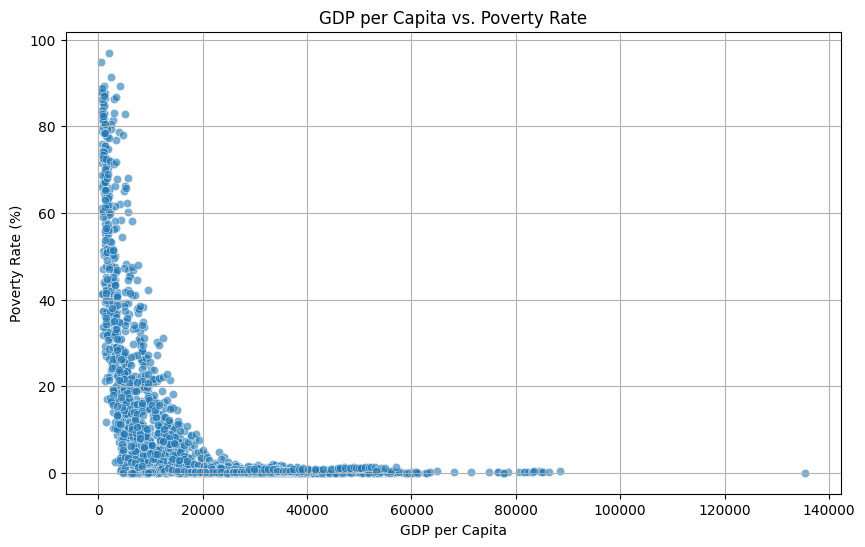

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation between 'gdp_per_capita' and 'poverty_rate'
# We drop NaN values for this calculation to ensure accuracy
correlation = df[['gdp_per_capita', 'poverty_rate']].dropna().corr().loc['gdp_per_capita', 'poverty_rate']
print(f"Correlation between GDP per Capita and Poverty Rate: {correlation:.2f}")

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.dropna(subset=['gdp_per_capita', 'poverty_rate']), x='gdp_per_capita', y='poverty_rate', alpha=0.6)
plt.title('GDP per Capita vs. Poverty Rate')
plt.xlabel('GDP per Capita')
plt.ylabel('Poverty Rate (%)')
plt.grid(True)
plt.show()

In [17]:
# Define a list of example Asian countries. You can extend this list as needed.
asian_countries = [
    'Afghanistan', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Bhutan',
    'Brunei Darussalam', 'Cambodia', 'China', 'Cyprus', 'Georgia', 'India',
    'Indonesia', 'Iran', 'Iraq', 'Israel', 'Japan', 'Jordan', 'Kazakhstan',
    'Kuwait', 'Kyrgyzstan', 'Laos', 'Lebanon', 'Malaysia', 'Maldives',
    'Mongolia', 'Myanmar', 'Nepal', 'North Korea', 'Oman', 'Pakistan',
    'Palestine', 'Philippines', 'Qatar', 'Saudi Arabia', 'Singapore',
    'South Korea', 'Sri Lanka', 'Syria', 'Taiwan', 'Tajikistan', 'Thailand',
    'Timor-Leste', 'Turkey', 'Turkmenistan', 'United Arab Emirates',
    'Uzbekistan', 'Vietnam', 'Yemen'
]

# Filter the DataFrame for Asian countries
df_asia = df[df['country'].isin(asian_countries)]

# Find the row with the maximum GDP for each Asian country, dropping NaNs,
# then select relevant columns and sort by year ascending.
result = df_asia.loc[df_asia.groupby('country')['gdp'].idxmax().dropna()]\
    [['country', 'year', 'gdp']].sort_values(by='year', ascending=True)

# Display the result
display(result)

,country,year,gdp
2888,Georgia,1988,7.802144e+10
5860,North Korea,1990,5.022395e+10
8850,Yemen,2010,1.116229e+11
7815,Syria,2010,1.437810e+11
4176,Kuwait,2016,2.258259e+11
4357,Lebanon,2017,7.503032e+10
3908,Japan,2018,4.852985e+12
8273,Turkmenistan,2018,9.763867e+10
7598,Sri Lanka,2018,2.802434e+11
6159,Palestine,2019,2.441037e+10


In [18]:
asian_countries = [
    'Afghanistan', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Bhutan',
    'Brunei Darussalam', 'Cambodia', 'China', 'Cyprus', 'Georgia', 'India',
    'Indonesia', 'Iran', 'Iraq', 'Israel', 'Japan', 'Jordan', 'Kazakhstan',
    'Kuwait', 'Kyrgyzstan', 'Laos', 'Lebanon', 'Malaysia', 'Maldives',
    'Mongolia', 'Myanmar', 'Nepal', 'North Korea', 'Oman', 'Pakistan',
    'Palestine', 'Philippines', 'Qatar', 'Saudi Arabia', 'Singapore',
    'South Korea', 'Sri Lanka', 'Syria', 'Taiwan', 'Tajikistan', 'Thailand',
    'Timor-Leste', 'Turkey', 'Turkmenistan', 'United Arab Emirates',
    'Uzbekistan', 'Vietnam', 'Yemen']
df_asia = df[df['country'].isin(asian_countries)]
result = df_asia.loc[df_asia.groupby('country')['gdp'].idxmax().dropna()]\
    [['country', 'year', 'gdp']].sort_values(by='year', ascending=True)

display(result)

IndentationError: unexpected indent (358502758.py, line 12)

In [19]:
asian_countries = [
    'Afghanistan', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Bhutan',
    'Brunei Darussalam', 'Cambodia', 'China', 'Cyprus', 'Georgia', 'India',
    'Indonesia', 'Iran', 'Iraq', 'Israel', 'Japan', 'Jordan', 'Kazakhstan',
    'Kuwait', 'Kyrgyzstan', 'Laos', 'Lebanon', 'Malaysia', 'Maldives',
    'Mongolia', 'Myanmar', 'Nepal', 'North Korea', 'Oman', 'Pakistan',
    'Palestine', 'Philippines', 'Qatar', 'Saudi Arabia', 'Singapore',
    'South Korea', 'Sri Lanka', 'Syria', 'Taiwan', 'Tajikistan', 'Thailand',
    'Timor-Leste', 'Turkey', 'Turkmenistan', 'United Arab Emirates',
    'Uzbekistan', 'Vietnam', 'Yemen']


In [21]:
print(asian_countries)

['Afghanistan', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Bhutan', 'Brunei Darussalam', 'Cambodia', 'China', 'Cyprus', 'Georgia', 'India', 'Indonesia', 'Iran', 'Iraq', 'Israel', 'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Lebanon', 'Malaysia', 'Maldives', 'Mongolia', 'Myanmar', 'Nepal', 'North Korea', 'Oman', 'Pakistan', 'Palestine', 'Philippines', 'Qatar', 'Saudi Arabia', 'Singapore', 'South Korea', 'Sri Lanka', 'Syria', 'Taiwan', 'Tajikistan', 'Thailand', 'Timor-Leste', 'Turkey', 'Turkmenistan', 'United Arab Emirates', 'Uzbekistan', 'Vietnam', 'Yemen']


In [32]:
df_2022_asia = df[(df['year'] == 2022) & (df['country'].isin(asian_countries))]


In [29]:
print(df_2022_asia)

                   country  year iso_code  population           gdp  \
42             Afghanistan  2022      AFG    40578847  5.330347e+10   
357                Armenia  2022      ARM     2880880  3.972173e+10   
492             Azerbaijan  2022      AZE    10295307  1.753706e+11   
582                Bahrain  2022      BHR     1533460  5.876976e+10   
627             Bangladesh  2022      BGD   169384891  8.581439e+11   
897                 Bhutan  2022      BTN      780921           NaN   
1302              Cambodia  2022      KHM    17201721  6.513659e+10   
1617                 China  2022      CHN  1425179562  2.696602e+13   
1977                Cyprus  2022      CYP     1331376  3.425501e+10   
2922               Georgia  2022      GEO     3794782  7.052861e+10   
3552                 India  2022      IND  1425423209  1.047625e+13   
3597             Indonesia  2022      IDN   278830527  3.500094e+12   
3642                  Iran  2022      IRN    89524247  1.572209e+12   
3687  

In [35]:
display(df_2022_asia)

,country,year,iso_code,population,gdp,gdp_per_capita,poverty_rate,gini_index,income_top1,income_top10,income_bottom50
42,Afghanistan,2022,AFG,40578847,5.330347e+10,1313.58,NaN,NaN,15.08,41.01,17.79
357,Armenia,2022,ARM,2880880,3.972173e+10,13788.06,1.896881,27.945295,15.00,39.60,18.59
492,Azerbaijan,2022,AZE,10295307,1.753706e+11,17034.03,NaN,NaN,13.99,38.22,20.33
582,Bahrain,2022,BHR,1533460,5.876976e+10,38324.94,NaN,NaN,25.59,57.75,10.38
627,Bangladesh,2022,BGD,169384891,8.581439e+11,5066.24,5.909079,30.930254,16.16,42.40,17.08
897,Bhutan,2022,BTN,780921,NaN,NaN,0.013378,28.459921,14.00,42.14,15.04
1302,Cambodia,2022,KHM,17201721,6.513659e+10,3786.63,NaN,NaN,18.13,45.38,13.91
1617,China,2022,CHN,1425179562,2.696602e+13,18921.14,0.000000,36.019513,15.76,43.46,13.51
1977,Cyprus,2022,CYP,1331376,3.425501e+10,25729.03,0.005062,31.534076,8.53,33.24,20.83
2922,Georgia,2022,GEO,3794782,7.052861e+10,18585.68,7.733272,33.500025,21.11,49.03,13.90


In [38]:
latin_america_countries = [
    'Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Costa Rica', 'Cuba',
    'Dominican Republic', 'Ecuador', 'El Salvador', 'Guatemala', 'Honduras',
    'Mexico', 'Nicaragua', 'Panama', 'Paraguay', 'Peru', 'Uruguay', 'Venezuela'
]